In [46]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans, MeanShift, SpectralClustering
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
import requests

In [2]:
# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

/tmp/ipykernel_17684/3291602058.py:7: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [57]:
print(data.shape)
print(names)

(15, 8860)
['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']


We start by considering the $t_{90}$ and $fluence$ values

In [ ]:
t90 = np.array(data[6, :], dtype=float)
fluence = np.array(data[9, :], dtype=float)

#cleaning the data, disgarding GRB's missing either or both t90 and fluence measurements
fluence_clean = []
t90_clean = []
for i in range(len(t90)):
    if (t90[i] == -999 or fluence[i] == 0.0 or fluence[i] == -999):
        continue
    fluence_clean.append(fluence[i])
    t90_clean.append(t90[i])
    
#getting the log10 of the considered data
lt90 = np.array(np.log10(t90_clean), dtype=float)
lfluence = np.array(np.log10(fluence_clean), dtype=float)


From physics we now that there are tow types of GRB's, short and long ones; we look for this double modality in the data:

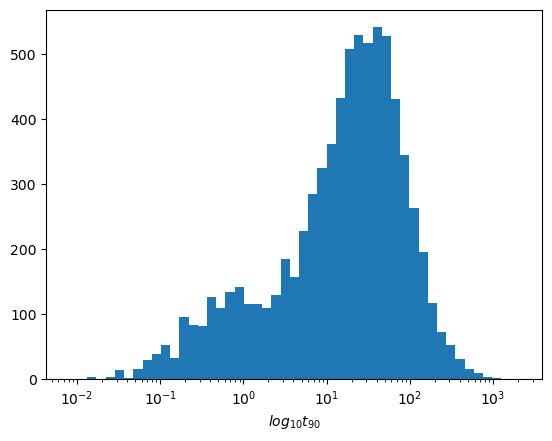

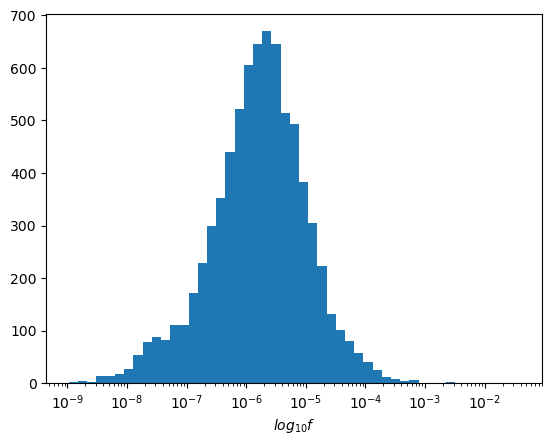

In [ ]:
# plotting hist of t90 values
bins = np.logspace(np.log10(min(t90_clean)), np.log10(max(t90_clean)), 50)
plt.hist(t90_clean, bins=bins)
plt.xscale('log')
plt.xlabel('$log_{10}t_{90}$')
plt.show()

#plotting hist of fluence values 
bins = np.logspace(np.log10(min(fluence_clean)), np.log10(max(fluence_clean)), 50)
plt.hist(fluence_clean, bins=bins)
plt.xscale('log')
plt.xlabel('$log_{10}f$')
plt.show()


From the $t_{90}$ histogram we suspect the presence of two populations (as expected by our knowledge). As for the $fluence$ we see a fatter left tail of the distribution, but the distinction is less clear compared to the first histogram.

We then try clustering considering only the $t_{90}$ values, and also using both $t_{90}$ and the fluences

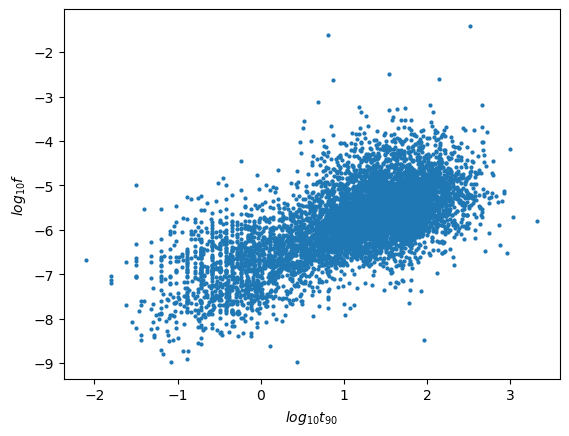

In [120]:
#scatter plot of the data considering the t90 and the fluence (logarithmic in both)
plt.scatter(lt90, lfluence, s=4)
plt.xlabel('$log_{10}t_{90}$')
plt.ylabel('$log_{10}f$')
plt.show()

We see a correlation between the two

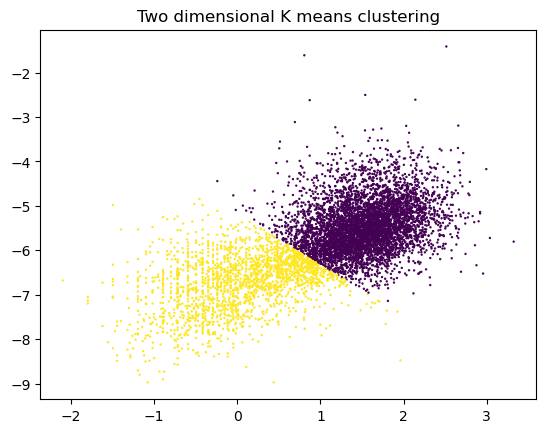

[[ 1.52565727 -5.45085987]
 [ 0.0772565  -6.71225114]]
Cluster centers in t90:
33.54727672578605
1.1946934986707336


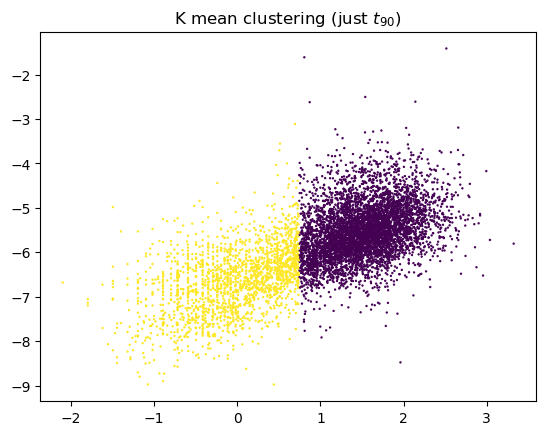

[[ 1.51995775]
 [-0.03153154]]
Cluster centers in t90:
33.10989113213337
0.9299689714438648


In [161]:

sk_data = np.hstack((lt90[:, np.newaxis], lfluence[:, np.newaxis])) #considering both variables and converting to sklearn format
sk_lt90 = lt90[:, np.newaxis] #only t90 values in sklearn format

# two dimensional K means clustering (K=2)
KMC = KMeans(n_clusters=2, n_init='auto')
labels = KMC.fit_predict(sk_data)

plt.scatter(lt90, lfluence, c=labels, s=0.5)
plt.title('Two dimensional K means clustering')
plt.show()

print(KMC.cluster_centers_) #log10
# t90 coordiates for the cluster centers
print('Cluster centers in t90:')
print(np.pow(10, KMC.cluster_centers_[0][0]))
print(np.pow(10, KMC.cluster_centers_[1][0]))

# K means clustering considering only t90
labels_s = KMC.fit_predict(sk_lt90)
plt.figure()
plt.scatter(lt90, lfluence, c=labels_s, s=0.5)
plt.title('K mean clustering (just $t_{90}$)')
plt.show()

print(KMC.cluster_centers_)
print('Cluster centers in t90:')
print(np.pow(10, KMC.cluster_centers_[0][0]))
print(np.pow(10, KMC.cluster_centers_[1][0]))


We move forward considering the clustering results relative just to $t_{90}$ (as the 2D trial shifts the threshold for long GRB's up to ~90s for small values of the fluence, which is way to large given our previous knowledge)

In [ ]:
lthold = 0.5*(min(lt90[labels_s==0])+max(lt90[labels_s==1]))
thold = np.pow(10, lthold) #threshold between the two populations (in t90)
print(thold)

5.543948051704669


We repeat the process with a different clustering algorithm (spectral clustering) and considering only $t_{90}$ values

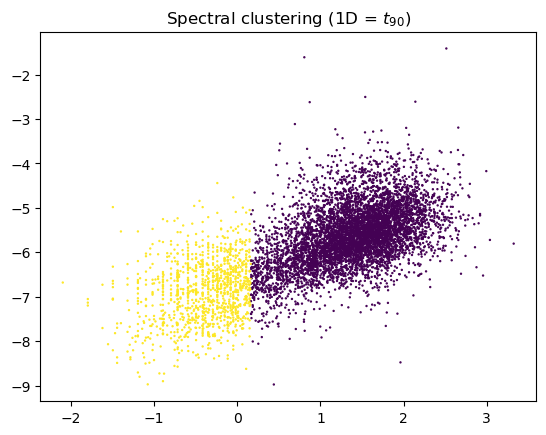

1.4554896083449034


In [ ]:
# spectral clustering 
spct = SpectralClustering(n_clusters=2)
labels_sc = spct.fit_predict(sk_lt90)
plt.scatter(lt90, lfluence, c=labels_sc, s=0.5)
plt.title('Spectral clustering (1D = $t_{90}$)')
plt.show()

#threshold
lthold_sc = 0.5*(min(lt90[labels_sc==0])+max(lt90[labels_sc==1]))
thold_sc = np.pow(10, lthold_sc)
print(thold_sc)

We compute our best estimate of the classification threshold by averaging the results obtainig with the two clustering algorithms:

In [ ]:
av_thold = np.mean([thold, thold_sc]) # average
print(av_thold)

3.430243647835479


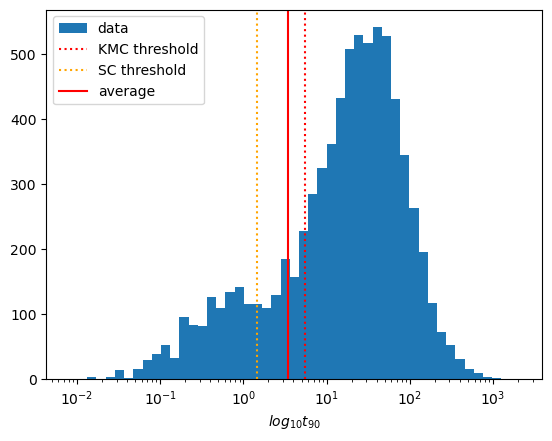

In [167]:
#plotting the data along with the threshold estimates
bins = np.logspace(np.log10(min(t90_clean)), np.log10(max(t90_clean)), 50)
plt.hist(t90_clean, bins=bins, label='data')
plt.axvline(thold, c='red', linestyle='dotted', label='KMC threshold')
plt.axvline(thold_sc, c='orange', linestyle='dotted', label='SC threshold')
plt.axvline(av_thold, c='red', label='average')
plt.xscale('log')
plt.xlabel('$log_{10}t_{90}$')
plt.legend()
plt.show()

From our analysis we estimate a threshold of $t_{90} = 3.43s$, the same order of magnitude as the typically reported value of about $2s$